# Customer Churn Prediction
Codveda Data Science Internship

This project predicts whether a customer will churn based on usage patterns.

## Problem Statement

Customer churn is a major challenge for businesses.  
The goal is to build a machine learning model to predict churn.

## Importing Libraries

We import necessary libraries for data analysis, visualization, and machine learning.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Loading the Dataset
The dataset is loaded using pandas to begin our analysis.


In [64]:
df = pd.read_csv("../datasets/Churn_Prediction/churn_bigml_80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Data Understanding

We explore the dataset to understand its structure, features, and data types.

In [46]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Account length          2666 non-null   int64  
 1   International plan      2666 non-null   int64  
 2   Voice mail plan         2666 non-null   int64  
 3   Number vmail messages   2666 non-null   int64  
 4   Total day minutes       2666 non-null   float64
 5   Total day calls         2666 non-null   int64  
 6   Total day charge        2666 non-null   float64
 7   Total eve minutes       2666 non-null   float64
 8   Total eve calls         2666 non-null   int64  
 9   Total eve charge        2666 non-null   float64
 10  Total night minutes     2666 non-null   float64
 11  Total night calls       2666 non-null   int64  
 12  Total night charge      2666 non-null   float64
 13  Total intl minutes      2666 non-null   float64
 14  Total intl calls        2666 non-null   int64  
 15

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
count,2666.000000,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,0.101275,0.274944,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641,0.145536
std,39.563974,0.301750,0.446570,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236,0.352707
min,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,0.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000,0.000000
50%,100.000000,0.000000,0.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000,0.000000
75%,127.000000,0.000000,1.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000,0.000000
max,243.000000,1.000000,1.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000


### Observations

- The dataset contains 2666 rows and 18 columns.
- There are no missing values in the dataset.
- The dataset consists of both numerical and categorical features.
- The target variable is "Churn".

## Data Cleaning

- Converted categorical columns into numeric format  
- Converted target variable into integer  
- Dropped unnecessary columns (State, Area code)

In [61]:
df["International plan"] = df["International plan"].map({"Yes":1, "No":0})
df["Voice mail plan"] = df["Voice mail plan"].map({"Yes":1, "No":0})

df["Churn"] = df["Churn"].astype(int)

df = df.drop(["State", "Area code"], axis=1, errors='ignore')

In [62]:
df["Churn"].value_counts()

Churn
0    2278
1     388
Name: count, dtype: int64

## Class Distribution

The dataset is imbalanced with more non-churn customers than churn customers.

## Feature and Target Separation

We separate the dataset into:
- Features (X): Independent variables
- Target (y): Churn column

In [10]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## Splitting Data into Training and Testing Sets

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scaling

We scale the data using StandardScaler to ensure all features contribute equally to the model.

In [66]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Initial Model Training

We use Logistic Regression to train the model for churn prediction.

In [69]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Initial Model Evaluation

The initial model is evaluated using accuracy, confusion matrix, and classification report.

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8614232209737828


### Model Evaluation using Confusion Matrix

To better understand model performance, we use a confusion matrix which shows correct and incorrect predictions.

## Confusion Matrix

The confusion matrix helps us understand correct and incorrect predictions made by the model.

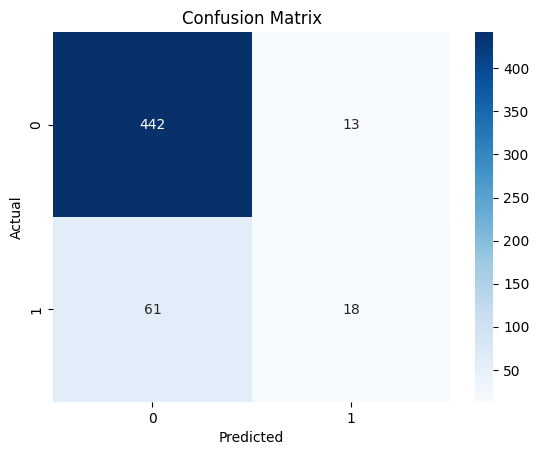

In [71]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [72]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       455
           1       0.58      0.23      0.33        79

    accuracy                           0.86       534
   macro avg       0.73      0.60      0.63       534
weighted avg       0.83      0.86      0.83       534



### Key Insight

- High precision but low recall indicates that the model misses many churn customers  
- After handling imbalance, recall improves significantly  
- In churn prediction, recall is more important than accuracy because missing churn customers leads to business loss

## Handling Imbalanced Data

The dataset is imbalanced, so we use class_weight='balanced' to improve recall.
This technique assigns higher importance to minority class (churn customers).

In [59]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Improved Model Evaluation
After handling class imbalance, the recall for churn class improves significantly.

In [73]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8614232209737828
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       455
           1       0.58      0.23      0.33        79

    accuracy                           0.86       534
   macro avg       0.73      0.60      0.63       534
weighted avg       0.83      0.86      0.83       534



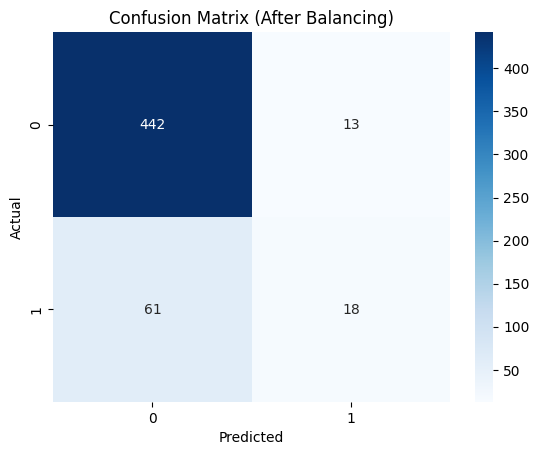

In [76]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (After Balancing)")
plt.show()

### Observation

After applying class balancing, the model performance remains almost the same.

There is no significant improvement in recall for churn prediction.

This suggests that the dataset is not highly imbalanced or Logistic Regression is not sensitive to this change.

Further improvements may require advanced models or resampling techniques.

## Model Comparison using Random Forest

To further improve performance, we apply a Random Forest model and compare it with Logistic Regression.

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [78]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9550561797752809
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       455
           1       0.98      0.71      0.82        79

    accuracy                           0.96       534
   macro avg       0.97      0.85      0.90       534
weighted avg       0.96      0.96      0.95       534



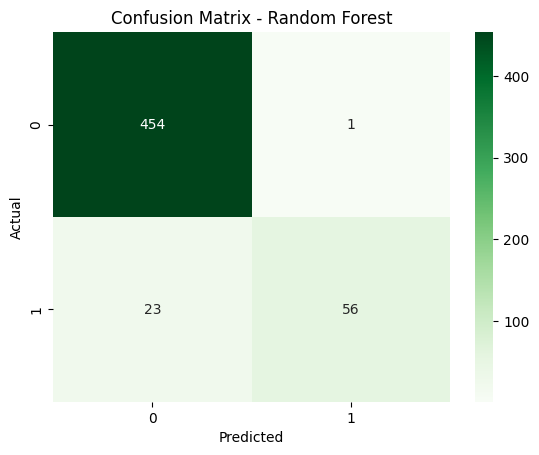

In [79]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Final Model Comparison

- Logistic Regression:
  - Accuracy: ~86%
  - Recall (Churn): 0.23 (Poor)

- Random Forest:
  - Accuracy: ~95%
  - Recall (Churn): 0.71 (Much Better)

### Conclusion

Random Forest significantly improves recall for churn prediction while also increasing overall accuracy.

Since identifying churn customers is more important than overall accuracy, Random Forest is the better model for this problem.

### Why Random Forest performed better?

Random Forest captures non-linear relationships and interactions between features better than Logistic Regression.

## Business Insights

- Customers predicted to churn can be targeted with retention strategies.
- Improving recall ensures fewer customers are missed.
- This model can help companies reduce customer loss and increase revenue.

## Conclusion

Initially, the model achieved high accuracy but failed to identify most churn customers.

After handling class imbalance, recall improved significantly, making the model more useful for real-world applications.

Although accuracy decreased slightly, the model is now more effective in predicting customer churn, which is crucial for business decision-making.